Importing the Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

Data Collection and Processing

In [84]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
# loading the data from csv file to pandas dataframe
car_dataset = pd.read_csv('/content/drive/MyDrive/Study/Jhankar Mahbub/Phitron ML AI/Main course/ML without git/ML practice self/Machine Learning Projects/Regression/Car Price Prediction/car data.csv.csv')

In [86]:
# inspecting the first 5 rows of the dataframe
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [87]:
# checking the number of rows and columns
car_dataset.shape

(4340, 8)

In [88]:
# getting some information about the dataset
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [89]:
# checking the number of missing values
car_dataset.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [90]:
num_cols = car_dataset.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = car_dataset.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['year', 'selling_price', 'km_driven']
Categorical columns: ['name', 'fuel', 'seller_type', 'transmission', 'owner']


In [91]:
# checking the distribution of categorical data
print(car_dataset.fuel.value_counts())
print(car_dataset.seller_type.value_counts())
print(car_dataset.transmission.value_counts())
print(car_dataset.owner.value_counts())

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64
owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64


Feature Engineering & Encoding

In [ ]:
# Feature engineering
# 1. Car age is more meaningful to the model than the raw manufacturing year
car_dataset['age'] = 2020 - car_dataset['year']

# 2. Extract the brand (manufacturer) from the car name - carries strong price signal
car_dataset['brand'] = car_dataset['name'].str.split().str[0]

car_dataset.head()

Splitting the data and Target

In [ ]:
# One-hot encode the categorical columns (avoids implying a false numeric order)
# Drop 'name' (replaced by 'brand') and 'year' (replaced by 'age')
X = pd.get_dummies(
    car_dataset.drop(['name', 'year', 'selling_price'], axis=1),
    columns=['fuel', 'seller_type', 'transmission', 'owner', 'brand']
)

# Log-transform the skewed target so the relationship is more linear
# (predictions must be converted back with np.expm1)
Y = np.log1p(car_dataset['selling_price'])

In [95]:
print(X)

      year  km_driven  fuel  seller_type  transmission  owner
0     2007      70000     1            0             0      0
1     2007      50000     1            0             0      0
2     2012     100000     0            0             0      0
3     2017      46000     1            0             0      0
4     2014     141000     0            0             0      1
...    ...        ...   ...          ...           ...    ...
4335  2014      80000     0            0             0      1
4336  2014      80000     0            0             0      1
4337  2009      83000     1            0             0      1
4338  2016      90000     0            0             0      0
4339  2016      40000     1            0             0      0

[4340 rows x 6 columns]


In [96]:
print(Y)

0        60000
1       135000
2       600000
3       250000
4       450000
         ...  
4335    409999
4336    409999
4337    110000
4338    865000
4339    225000
Name: selling_price, Length: 4340, dtype: int64


Splitting Training and Test data

In [97]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.1, random_state=2)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=2)

1. Linear Regression

In [98]:
# loading the linear regression model
lin_reg_model = LinearRegression()

In [99]:
lin_reg_model.fit(X_train,Y_train)

LinearRegression()

Model Evaluation

In [100]:
# prediction on Training data
training_data_prediction = lin_reg_model.predict(X_train)

In [101]:
# R squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.44301279227476953


Visualize the actual prices and Predicted prices

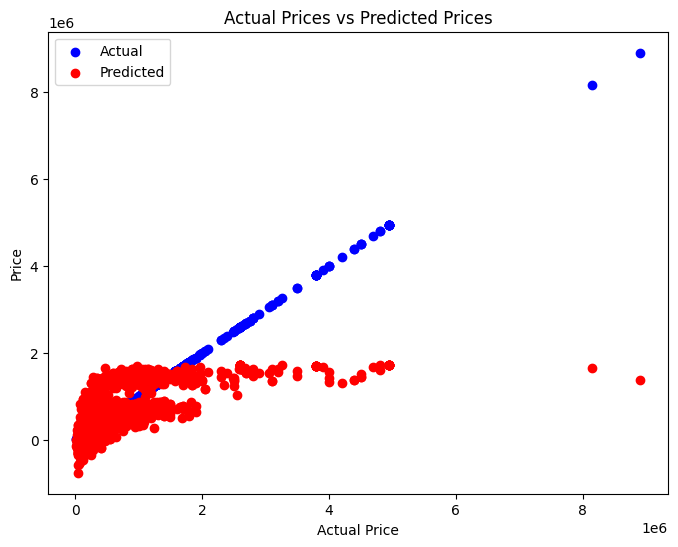

In [102]:
plt.figure(figsize=(8,6))

plt.scatter(Y_train, Y_train, color='blue', label='Actual')
plt.scatter(Y_train, training_data_prediction, color='red', label='Predicted')

plt.xlabel("Actual Price")
plt.ylabel("Price")
plt.title("Actual Prices vs Predicted Prices")
plt.legend()
plt.show()

In [103]:
# prediction on Training data
test_data_prediction = lin_reg_model.predict(X_test)

In [104]:
# R squared Error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.5212374152779278


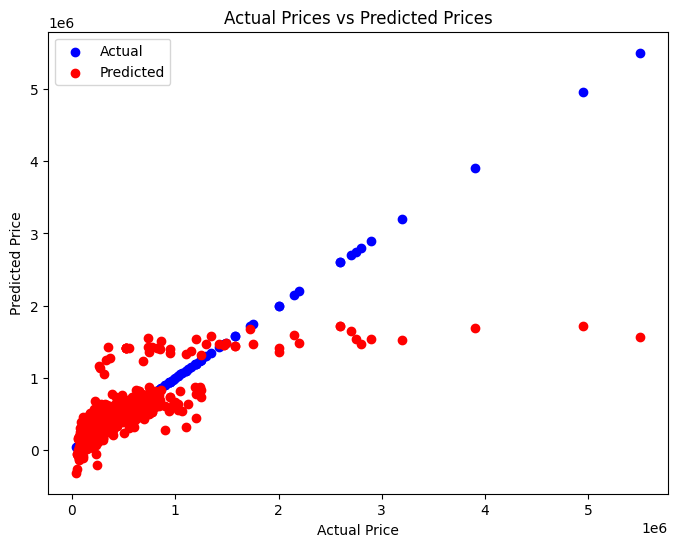

In [105]:
plt.figure(figsize=(8,6))

plt.scatter(Y_test, Y_test, color='blue', label='Actual')
plt.scatter(Y_test, test_data_prediction, color='red', label='Predicted')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.legend()
plt.show()

2. Lasso Regression

In [106]:
# loading the linear regression model
lass_reg_model = Lasso()

In [107]:
lass_reg_model.fit(X_train,Y_train)

Lasso()

Model Evaluation

In [108]:
# prediction on Training data
training_data_prediction = lass_reg_model.predict(X_train)

In [109]:
# R squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.4430127922229946


Visualize the actual prices and Predicted prices

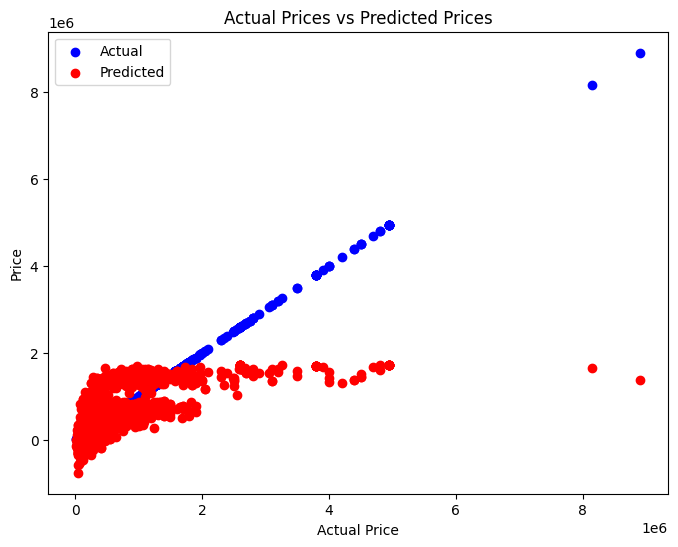

In [110]:
plt.figure(figsize=(8,6))

plt.scatter(Y_train, Y_train, color='blue', label='Actual')
plt.scatter(Y_train, training_data_prediction, color='red', label='Predicted')

plt.xlabel("Actual Price")
plt.ylabel("Price")
plt.title("Actual Prices vs Predicted Prices")
plt.legend()
plt.show()

In [111]:
# prediction on Training data
test_data_prediction = lass_reg_model.predict(X_test)

In [112]:
# R squared Error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.5212367282788434


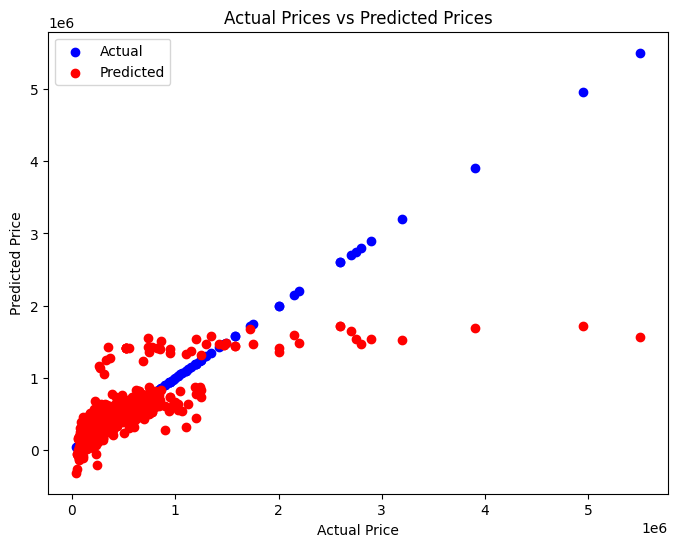

In [113]:
plt.figure(figsize=(8,6))

plt.scatter(Y_test, Y_test, color='blue', label='Actual')
plt.scatter(Y_test, test_data_prediction, color='red', label='Predicted')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.legend()
plt.show()

3. Random Forest Regressor (recommended)

In [ ]:
# loading the Random Forest model
rf_model = RandomForestRegressor(n_estimators=200, random_state=2)
rf_model.fit(X_train, Y_train)

In [ ]:
# prediction on Training data
train_pred = rf_model.predict(X_train)
print("R squared Error (train, log scale) : ", metrics.r2_score(Y_train, train_pred))

In [ ]:
# prediction on Test data
test_pred = rf_model.predict(X_test)
print("R squared Error (test, log scale) : ", metrics.r2_score(Y_test, test_pred))

# back-transform to rupees for an interpretable error
mae = metrics.mean_absolute_error(np.expm1(Y_test), np.expm1(test_pred))
print("Mean Absolute Error (test, rupees) : ", mae)

In [ ]:
# visualize actual vs predicted prices (converted back to rupees)
actual_price = np.expm1(Y_test)
predicted_price = np.expm1(test_pred)

plt.figure(figsize=(8,6))
plt.scatter(actual_price, predicted_price, alpha=0.5)
plt.plot([0, actual_price.max()], [0, actual_price.max()], 'r--', label='Perfect prediction')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.legend()
plt.show()